<a href="https://colab.research.google.com/github/nithzsenpai/mL-lab/blob/main/1BM23CS219_LAB7_RANDOMFOREST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Build a Random Forest (RF) classifier to classify IRIS flower dataset

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (assuming it's already in the kernel as 'df' or from the provided path)
# If 'df' is not in the kernel or is not the correct dataset, uncomment the line below:
df = pd.read_csv('/content/iris (2).csv')

# Separate features (X) and target (y)
X = df.drop('species', axis=1) # Assuming 'species' is the target column
y = df['species']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Dataset loaded and split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Dataset loaded and split into training and testing sets.
X_train shape: (105, 4)
X_test shape: (45, 4)


### 2. Measure prediction score using default `n_estimators` (10)

In [7]:
# Initialize the Random Forest Classifier with default n_estimators (10)
rf_classifier_default = RandomForestClassifier(random_state=42) # Default n_estimators is 10 in older scikit-learn, newer versions have 100

# Train the model
rf_classifier_default.fit(X_train, y_train)

# Make predictions on the test set
y_pred_default = rf_classifier_default.predict(X_test)

# Calculate the accuracy score
accuracy_default = accuracy_score(y_test, y_pred_default)

print(f"Prediction score with default n_estimators (which is {rf_classifier_default.n_estimators}): {accuracy_default:.4f}")

Prediction score with default n_estimators (which is 100): 0.8889


### 3. Fine-tune the model by changing the number of trees (`n_estimators`)

In [8]:
# Define a range of n_estimators to test
n_estimators_range = np.arange(10, 201, 10) # From 10 to 200, step by 10

best_score = 0
best_n_estimators = 0
scores = []

for n_estimators in n_estimators_range:
    rf_classifier = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    rf_classifier.fit(X_train, y_train)
    y_pred = rf_classifier.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    scores.append(score)

    if score > best_score:
        best_score = score
        best_n_estimators = n_estimators

print(f"\nBest prediction score: {best_score:.4f}")
print(f"Number of trees for best score: {best_n_estimators}")


Best prediction score: 0.9111
Number of trees for best score: 10


### 4. Visualize the scores for different `n_estimators`

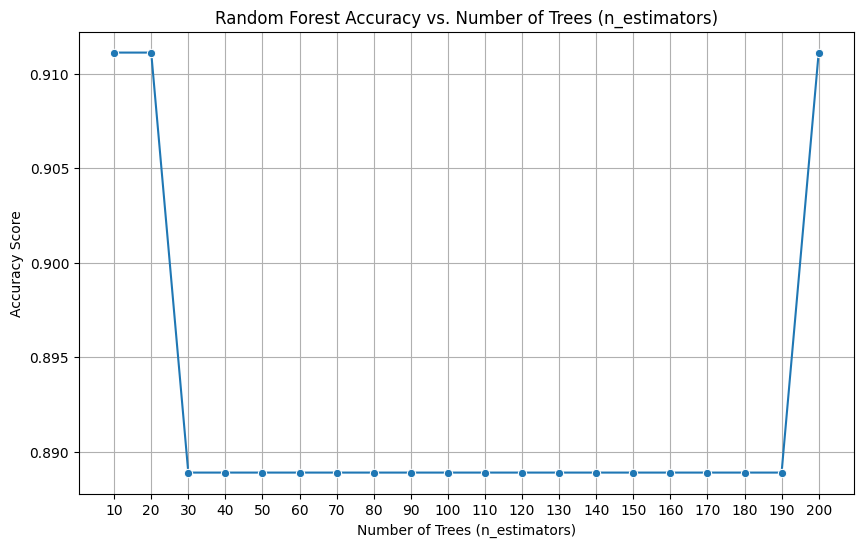

In [9]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=n_estimators_range, y=scores, marker='o')
plt.title('Random Forest Accuracy vs. Number of Trees (n_estimators)')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy Score')
plt.grid(True)
plt.xticks(n_estimators_range)
plt.show()